In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'

print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [2]:
import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
def onehot_label(cls: int):
    cls = torch.tensor(cls).long()
    return F.one_hot(cls, num_classes=10)

train = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=True,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

eval = tds.FashionMNIST(
    root=dataset_root,
    download=True,
    train=False,
    transform=tvf.pil_to_tensor,
    target_transform=onehot_label,
)

torch.Size([60000, 28, 28])


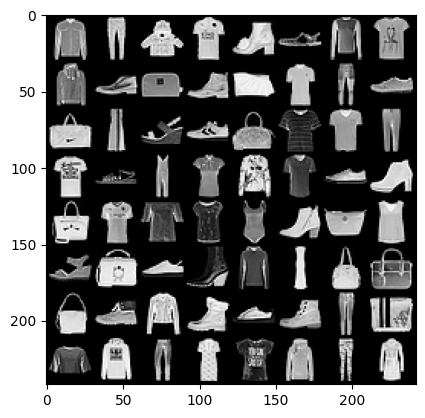

In [4]:
def random_grid(imgs, sz: int):
    samples_ix = torch.randint(low=0, high=len(imgs) - 1, size=(sz,))
    samples = imgs[samples_ix]
    grid = tu.make_grid(samples.unsqueeze(1))
    return grid.permute(1, 2, 0)

print(train.data.shape)

tmps = random_grid(train.data, 64)
plt.imshow(tmps)

In [5]:
class MyNn(nn.Module):
    def __init__(self, in_sz, out_sz, hidden_sz=128):
        super().__init__()
        self.in_sz = in_sz
        self.out_sz = out_sz
        self.lin1 = nn.Linear(in_sz, hidden_sz, bias=True)
        self.lin2 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin3 = nn.Linear(hidden_sz, hidden_sz, bias=True)
        self.lin4 = nn.Linear(hidden_sz, out_sz, bias=True)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = x.reshape(-1, self.in_sz)
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        x = F.relu(x)
        x = self.lin3(x)
        x = F.relu(x)
        x = self.lin4(x)
        return x

class MyCnn(nn.Module):
    def __init__(self, out_sz=10, ch=32):
        super().__init__()

        self.channels = ch
        self.out_sz = out_sz
        # (32x32)
        self.conv1_1 = nn.Conv2d(1, ch, kernel_size=3, stride=1, padding=1)
        # self.bn1 = nn.BatchNorm2d(ch)
        self.conv1_2 = nn.Conv2d(ch, ch*2, kernel_size=3, stride=1, padding=1)
        # self.bn2 = nn.BatchNorm2d(ch*2)

        # (16x16)
        self.conv2_1 = nn.Conv2d(ch*2, ch*2, kernel_size=3, stride=1, padding=1)
        # self.bn3 = nn.BatchNorm2d(ch*2)
        self.conv2_2 = nn.Conv2d(ch*2, ch*4, kernel_size=3, stride=1, padding=1)
        # self.bn4 = nn.BatchNorm2d(ch*4)

        # (8x8
        self.inner = None
        self.lin1 = nn.Linear(ch*4 * 7 * 7, 128, bias=True)
        self.lin2 = nn.Linear(128, out_sz, bias=True)

    def forward(self, x):
        x = self.conv1_1(x)
        # x = self.bn1(x)
        x = F.relu(x)
        x = self.conv1_2(x)
        # x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = self.conv2_1(x)
        # x = self.bn2(x)
        x = F.relu(x)
        x = self.conv2_2(x)
        # x = self.bn4(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)

        x = x.view(-1, self.channels*4 * 7 * 7)
        self.inner = x
        x = self.lin1(x)
        x = F.relu(x)
        x = self.lin2(x)
        return x

    def get_inner(self):
        return self.inner.clone()
        

In [6]:
batchsize = 512

train_loader = tud.DataLoader(train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(eval, batch_size=batchsize, shuffle=True)

In [7]:
from torchinfo import summary
testmodel = MyCnn(out_sz=10, ch=16)
summary(testmodel, (1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
MyCnn                                    [1, 10]                   --
├─Conv2d: 1-1                            [1, 16, 28, 28]           160
├─Conv2d: 1-2                            [1, 32, 28, 28]           4,640
├─Conv2d: 1-3                            [1, 32, 14, 14]           9,248
├─Conv2d: 1-4                            [1, 64, 14, 14]           18,496
├─Linear: 1-5                            [1, 128]                  401,536
├─Linear: 1-6                            [1, 10]                   1,290
Total params: 435,370
Trainable params: 435,370
Non-trainable params: 0
Total mult-adds (M): 9.60
Input size (MB): 0.00
Forward/backward pass size (MB): 0.45
Params size (MB): 1.74
Estimated Total Size (MB): 2.20

Epoch 0: 0.5947878956794739 
Current LR is [0.01]
7703/10000 correct, 77.03%
Epoch 1: 0.5318673849105835 
Current LR is [0.01]
8010/10000 correct, 80.10%
Epoch 2: 0.4326190948486328 
Current LR is [0.01]
8444/10000 correct, 84.44%
Epoch 3: 0.40242019295692444 
Current LR is [0.01]
8527/10000 correct, 85.27%
Epoch 4: 0.4349656105041504 
Current LR is [0.01]
8445/10000 correct, 84.45%
Epoch 5: 0.42897194623947144 
Current LR is [0.01]
8500/10000 correct, 85.00%
Epoch 6: 0.38798874616622925 
Current LR is [0.01]
8537/10000 correct, 85.37%
Epoch 7: 0.39578506350517273 
Current LR is [0.01]
8466/10000 correct, 84.66%
Epoch 8: 0.42207303643226624 
Current LR is [0.01]
8487/10000 correct, 84.87%
Epoch 9: 0.42473793029785156 
Current LR is [0.01]
8426/10000 correct, 84.26%
Epoch 10: 0.3029075264930725 
Current LR is [0.005]
8883/10000 correct, 88.83%
Epoch 11: 0.30444177985191345 
Current LR is [0.005]
8868/10000 correct, 88.68%
Epoch 12: 0.2981240153312683 
Current LR is [0.005]
8921/10000 co

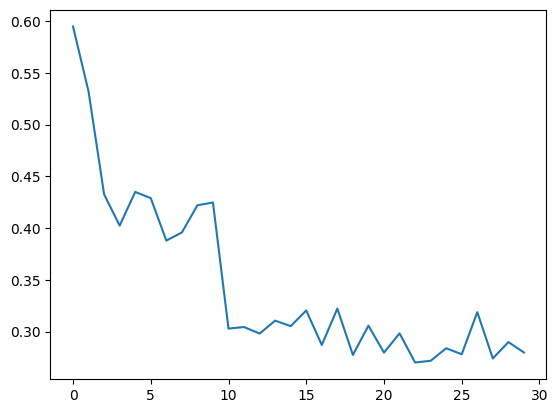

In [10]:
device='cuda'
model = MyCnn(out_sz=10, ch=8).to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

lossfn = nn.CrossEntropyLoss()
epochs = 30

loss_plot = []
for epoch in range(epochs):
    model.train()
    for i, (images, target) in enumerate(train_loader):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.float().to(device)

        outs = model(images)
        loss = lossfn(outs, targets.view(-1, 10))
        loss.backward()
        optimizer.step()

    losses = []
    correct = 0
    total = len(eval)
    if epoch % 1 == 0:
        for i, (images, target) in enumerate(val_loader):
            with torch.no_grad():
                images = images.float().to(device)
                targets = target.float().to(device)
                outs = model(images)
    
                loss = lossfn(outs, targets.view(-1, 10))
                losses.append(loss)
                for x in range(outs.shape[0]):
                    preds = F.softmax(outs, dim=1)
                    cls = preds[x].argmax()
                    lbl = targets.view(-1, 10)[x].argmax()
                    if cls == lbl:
                        correct += 1

        epoch_loss = torch.Tensor(losses).mean().item()
        print("Epoch {}: {} ".format(epoch, epoch_loss))
        print("Current LR is {}".format(scheduler.get_last_lr()))
        print("{}/{} correct, {:.2f}%".format(correct, total, 100*correct/total))
        loss_plot.append(epoch_loss)
        scheduler.step()

plt.plot(loss_plot)

EPOCH: 0, LOSS 0.106063
EPOCH: 1000, LOSS 0.159578
EPOCH: 2000, LOSS 0.207977
EPOCH: 3000, LOSS 0.280744
EPOCH: 4000, LOSS 0.382586
EPOCH: 5000, LOSS 0.506239
EPOCH: 6000, LOSS 0.626080
EPOCH: 7000, LOSS 0.721247
EPOCH: 8000, LOSS 0.789105
EPOCH: 9000, LOSS 0.835121
EPOCH: 10000, LOSS 0.866584
EPOCH: 11000, LOSS 0.889087
EPOCH: 12000, LOSS 0.905612
EPOCH: 13000, LOSS 0.918032
EPOCH: 14000, LOSS 0.927672
EPOCH: 15000, LOSS 0.935440
EPOCH: 16000, LOSS 0.941751
EPOCH: 17000, LOSS 0.947051
EPOCH: 18000, LOSS 0.951537
EPOCH: 19000, LOSS 0.955338
EPOCH: 20000, LOSS 0.958603
EPOCH: 21000, LOSS 0.961429
EPOCH: 22000, LOSS 0.963957
EPOCH: 23000, LOSS 0.966198
EPOCH: 24000, LOSS 0.968175
EPOCH: 25000, LOSS 0.969935
EPOCH: 26000, LOSS 0.971518
EPOCH: 27000, LOSS 0.972952
EPOCH: 28000, LOSS 0.974246
EPOCH: 29000, LOSS 0.975422
EPOCH: 30000, LOSS 0.976501
EPOCH: 31000, LOSS 0.977490
EPOCH: 32000, LOSS 0.978397
EPOCH: 33000, LOSS 0.979234
EPOCH: 34000, LOSS 0.980010
EPOCH: 35000, LOSS 0.980728
EPOCH

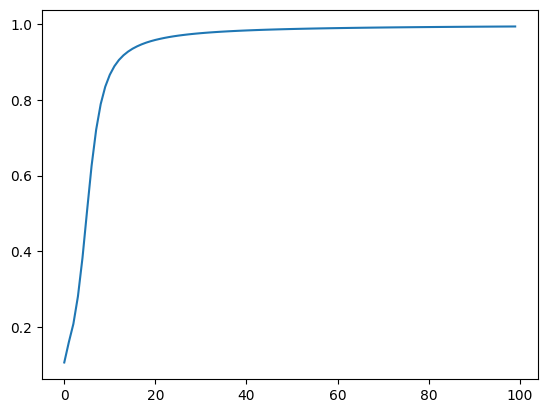

In [16]:
import copy

# Disable gradient computation, freezing the weights
frozen_model = copy.deepcopy(model)
frozen_model.requires_grad_(False)
frozen_model.eval()

epochs = 100000

# Multiply by a onehot vector to "select" an index.
def idx_loss(v, index, numcls=10):
    tmp = F.one_hot(torch.tensor(index), numcls).to(device, dtype=torch.float32)
    tmp.requires_grad_(True)
    out = v*tmp
    return out.sum()

im = torch.randn(1, 1, 28, 28, requires_grad=True, device=device, dtype=torch.float32)

optimizer = torch.optim.SGD(
    [im],
    lr=5.0,
    maximize=True
)

losses = []

for epoch in range(epochs):
    optimizer.zero_grad()

    outs = frozen_model(im)
    outs = F.softmax(outs, dim=1)

    # Change the second arg to change the image to train for
    loss = idx_loss(outs, 3, 10)
 
    loss.backward()
    optimizer.step()
    if epoch % (epochs/100) == 0:
        print("EPOCH: {}, LOSS {:.6f}".format(epoch, loss.item()))
        losses.append(loss.item())

plt.plot(losses)

torch.float32 67.30597686767578 -34.71280288696289
torch.float32 1.0 0.0


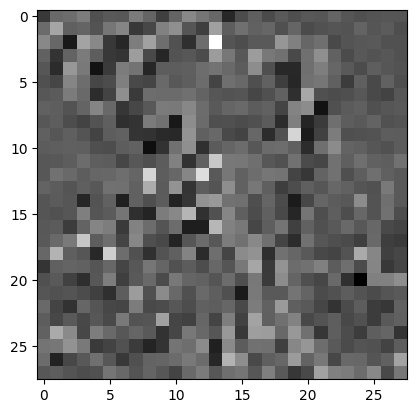

In [17]:
print(im.dtype, im.max().item(), im.min().item())
z = im.clone()
z += z.min().abs()
z /= z.max()
print(z.dtype, z.max().item(), z.min().item())
plt.imshow(z.detach().cpu().permute(0, 2, 3, 1)[0],cmap='gray')